# **CDS Project: Part 3**

*Institute of Software Security (E22)*  
*Hamburg University of Technology*  

## Learning objectives
---

- Choose an ML model architecture for vulnerability prediction
- Preprocess the dataset you created in project part 2 to fit the model you selected
- Split the dataset for cross validation
- Create the model training pipeline, train the model using the train set and optimize the model using the test set
- Create loss graphs of the learning behaviour
- Generate predictions for the validation set
- Evaluate the results using appropriate metrics (add questions: reduce overfitting? optional 5-fold cross validation)


## Materials
---

- Lecture Slides 2, 3, 5 and 6, 9.
- PyTorch Documentation: [Datasets and Data Loaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) 
- 


## Project Description

In this project, you will create, train and evaluate your own machine learning model to predict vulnerabilities in source code. In addition, you will preprocess the data to prepare it to be used in the learning pipeline.
You will be using the dataset created in part 2 in this part. 

## **Task 1**

- There are several ML model architectures that you can use for vulnerabilitiy prediction such as RNN, CNN, Multilabel Perceptron (MLP), Gated Recurrent Units (GRU) and so on. Choose a suitable ML model architecture for your project based on the strenghts and weaknesses of these algorithms.

- For the model architecture, you can choose from 2 paths:
  1. Preprocess the functions into vectors and continue the learning process similar to project 1.
  For instance, the code in the dataset needs to be converted into some type of vector representation that can be processed by a machine. After selecting a suitable model, preprocess the content in your dataset accordingly. Several models are available to preprocess code data such as:
    - Code2Vec: https://code2vec.org/
    - CodeBERT: https://github.com/microsoft/CodeBERT/tree/master/UniXcoder
    - CodeT5: https://github.com/salesforce/CodeT5

  2. Choose a model architecture that is capable of handeling raw text inputs (LSTM, GRU, etc.) as an input layer. Further information on text processing using pytorch:
    - https://pytorch.org/text/stable/index.html
    - https://pytorch.org/tutorials/

Answer - Selected CodeBERT-family embeddings with an MLP classifier. The implementation uses `huggingface/CodeBERTa-small-v1`, which is pretrained on programming-language data and can convert source-code functions into fixed-size numeric vectors. These embeddings are then passed into an MLP binary classifier to predict whether a function is vulnerable or non-vulnerable. This follows the lecture pipeline of code -> tokens -> vectors -> model. This approach is also computationally simpler than fine-tuning a full transformer because the pretrained code model is mainly used as a feature extractor.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/CDS_Part3/vulnerability_labeled_dataset.jsonl"
challenge_path = "/content/drive/MyDrive/CDS_Part3/cds_challenge.jsonl"
submission_path = "/content/drive/MyDrive/CDS_Part3/part3_challenge_predictions_5.csv"

In [40]:
!pip install transformers scikit-learn matplotlib

## Task 2

- Split your dataset appropriately into train, test, and validation set and justify your split.  

Answer - 
The dataset was split into approximately 70% training, 15% validation, and 15% test data. This split was chosen because it gives most of the data to the training set while still keeping two separate evaluation sets. Since the final dataset is not extremely large and the model needs enough examples to learn useful vulnerability patterns, 70% of the data was used for training. At the same time, using all remaining data only for testing would not leave a separate set for model selection, so the remaining 30% was divided equally into validation and test sets.

The 15% validation set was used during development to compare model settings, monitor validation loss, and tune the decision threshold for F1-score. The 15% test set was kept separate and used only after training and threshold tuning to estimate how well the selected model performs on unseen data. This avoids using the same data both for model selection and final evaluation.

A larger training split, such as 80%-10%-10%, would give more training data but smaller validation and test sets, making the evaluation less stable. A smaller training split, such as 60%-20%-20%, would give more evaluation data but fewer training examples, which is not ideal because the MLP classifier needs enough samples to learn from the CodeBERTa embeddings. Therefore, 70%-15%-15% was a balanced choice between training data size and reliable validation/test evaluation.

The split was also done group-wise using `fix_commit`. This means all method examples generated from the same fixing commit were kept in the same split. This was important because one fixing commit can create a vulnerable method version before the fix and a fixed method version after the fix. These two versions can be almost identical except for the security fix. If one version appeared in training and the other appeared in testing, the model would be evaluated on code that is very similar to something it had already seen, causing data leakage and making the performance look better than it really is. Grouping by `fix_commit` gives a more realistic evaluation because the test set contains commits that were not seen during training.

In [41]:
# TODO: Load the dataset

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

# dataset_path is configured in the first cell.
# In local mode, it points to ../Part2/vulnerability_labeled_dataset.jsonl.

# Load the JSONL dataset.
dataset_df = pd.read_json(dataset_path, lines=True)

# Keep only rows where function code and label are available.
dataset_df = dataset_df.dropna(subset=["function_code", "vulnerable"])

# Make sure the label is stored as an integer: vulnerable=True -> 1, vulnerable=False -> 0.
dataset_df["label"] = dataset_df["vulnerable"].astype(int)

# Show the dataset size and label distribution.
print("Total samples:", len(dataset_df))
print(dataset_df["label"].value_counts())

# TODO: Split the dataset into train, test and validation set

# Use fix_commit as the grouping column to reduce data leakage.
# This keeps records from the same fixing commit in the same split.
group_column = "fix_commit"

# Create one row per unique fixing commit with its first observed label.
groups_df = dataset_df[[group_column, "label"]].drop_duplicates(subset=[group_column])

# First split: 70% train groups, 30% temporary groups.
train_groups, temp_groups = train_test_split(
    groups_df[group_column],
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Second split: split temporary groups into 15% validation and 15% test.
validation_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

# Create the actual train, validation, and test DataFrames.
train_df = dataset_df[dataset_df[group_column].isin(train_groups)].reset_index(drop=True)
validation_df = dataset_df[dataset_df[group_column].isin(validation_groups)].reset_index(drop=True)
test_df = dataset_df[dataset_df[group_column].isin(test_groups)].reset_index(drop=True)

# Print split sizes.
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

# Print label distribution in each split.
print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation label distribution:")
print(validation_df["label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True))

Total samples: 16014
label
0    8029
1    7985
Name: count, dtype: int64
Train samples: 10852
Validation samples: 2420
Test samples: 2742

Train label distribution:
label
0    0.501659
1    0.498341
Name: proportion, dtype: float64

Validation label distribution:
label
0    0.50124
1    0.49876
Name: proportion, dtype: float64

Test label distribution:
label
0    0.500365
1    0.499635
Name: proportion, dtype: float64


## Task 3
- Create a preprocessing and training/test pipeline. This can also be done in separate steps.
- Train the model on a small dataset (e.g.: 1000 samples depending on the computational capacity) and make sure everything is working properly
- Show a graph showing the changes in loss function druring the training epochs 
- Select proper metrics to evaluate the performance of the model
- If everything works well, then change the model parameters (e.g: number of neurons, layer depth) and regenerate the results. Comapare these results with your previous results and elaborate your findings.

Answer (Comparison and findings)-

After confirming that the full pipeline worked, the model parameters were changed and the results were regenerated. The first working model used CodeBERTa-small embeddings with a simpler MLP classifier and a smaller sample size. This baseline was mainly used to confirm that dataset loading, embedding generation, model training, evaluation, and challenge prediction were working correctly.

Then, the MLP classifier was improved by increasing the number of neurons and adding another hidden layer. The improved classifier used the architecture 'input_size -> 256 -> 128 -> 1', with ReLU activation functions and dropout layers of 0.4 and 0.3. The training sample size was also increased to 1,000 training samples, 250 validation samples, and 250 test samples. The model was trained for 10 epochs using BCEWithLogitsLoss and the Adam optimizer.

The baseline model achieved a local test F1-score of about 0.578. After increasing the model capacity and using more training data, the improved MLP achieved a local test F1-score of about 0.672. This showed that the deeper MLP was able to learn better from the CodeBERTa embeddings than the first simple baseline.

However, the improvement was not perfect. The improved model had high recall, meaning it detected many vulnerable examples, but precision was still low, meaning many non-vulnerable examples were incorrectly classified as vulnerable. This also appeared on the leaderboard, where the best submitted model achieved high recall but modest precision.

A direct fine-tuning experiment with 'microsoft/codebert-base' was also tested. It achieved a higher local F1-score than the improved MLP, but it performed worse on the leaderboard. This showed that better local performance did not always transfer to the hidden challenge set. The best submitted result came from the improved MLP trained on CodeBERTa-small embeddings with a final threshold of 0.40.

Overall, changing the number of neurons, layer depth, dropout, and training sample size improved the model compared with the first baseline. The main finding was that a moderately sized MLP on top of CodeBERTa embeddings generalized better than the more complex fine-tuned transformer for this challenge.

In [42]:
# TODO: Implement your ML pipeline and perform evaluation
# NumPy is used for metric arrays and probability handling.
import numpy as np

# PyTorch is used to define, train, and evaluate the classifier.
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Transformers loads the pretrained code tokenizer and model.
from transformers import AutoTokenizer, AutoModel

# Matplotlib is used to plot training and validation loss.
import matplotlib.pyplot as plt

# Scikit-learn metrics are used for final evaluation.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Select GPU if available, otherwise use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Use a larger subset for the second experiment.
train_small_df = train_df.sample(
    n=min(1000, len(train_df)),
    random_state=42
).reset_index(drop=True)

validation_small_df = validation_df.sample(
    n=min(250, len(validation_df)),
    random_state=42
).reset_index(drop=True)

test_small_df = test_df.sample(
    n=min(250, len(test_df)),
    random_state=42
).reset_index(drop=True)

print("Train size:", len(train_small_df))
print("Validation size:", len(validation_small_df))
print("Test size:", len(test_small_df))

# Load a smaller CodeBERT-family model for the first CPU trial.
# This is faster to download and run than UniXcoder on CPU.
model_name = "huggingface/CodeBERTa-small-v1"

print("Loading pretrained code model:", model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
embedding_model = AutoModel.from_pretrained(model_name).to(device)
print("Model loaded successfully.")

# The pretrained model is used only to create embeddings.
embedding_model.eval()

def create_embeddings(texts, batch_size=16, max_length=128):
    embeddings = []
    total_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():
        for batch_number, start in enumerate(range(0, len(texts), batch_size), start=1):
            batch_texts = texts[start:start + batch_size]

            if batch_number == 1 or batch_number % 10 == 0 or batch_number == total_batches:
                print(f"Embedding batch {batch_number}/{total_batches}")

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {
                key: value.to(device)
                for key, value in encoded.items()
            }

            outputs = embedding_model(**encoded)

            batch_embeddings = outputs.last_hidden_state[:, 0, :]

            embeddings.append(batch_embeddings.cpu())

    return torch.cat(embeddings, dim=0)

print("Creating train embeddings...")
X_train = create_embeddings(train_small_df["function_code"].tolist())

print("Creating validation embeddings...")
X_validation = create_embeddings(validation_small_df["function_code"].tolist())

print("Creating test embeddings...")
X_test = create_embeddings(test_small_df["function_code"].tolist())

y_train = torch.tensor(train_small_df["label"].values, dtype=torch.float32).view(-1, 1)
y_validation = torch.tensor(validation_small_df["label"].values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(test_small_df["label"].values, dtype=torch.float32).view(-1, 1)

print("Train embedding shape:", X_train.shape)
print("Validation embedding shape:", X_validation.shape)
print("Test embedding shape:", X_test.shape)

Using device: cuda
Train size: 1000
Validation size: 250
Test size: 250
Loading pretrained code model: huggingface/CodeBERTa-small-v1


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: huggingface/CodeBERTa-small-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.
Creating train embeddings...
Embedding batch 1/63
Embedding batch 10/63
Embedding batch 20/63
Embedding batch 30/63
Embedding batch 40/63
Embedding batch 50/63
Embedding batch 60/63
Embedding batch 63/63
Creating validation embeddings...
Embedding batch 1/16
Embedding batch 10/16
Embedding batch 16/16
Creating test embeddings...
Embedding batch 1/16
Embedding batch 10/16
Embedding batch 16/16
Train embedding shape: torch.Size([1000, 768])
Validation embedding shape: torch.Size([250, 768])
Test embedding shape: torch.Size([250, 768])


In [43]:
# Create DataLoaders
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    TensorDataset(X_validation, y_validation),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

In [44]:
# Define the improved MLP used for the best leaderboard upload.
class VulnerabilityMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)


In [45]:
# Create the improved MLP model.
classifier = VulnerabilityMLP(
    input_size=X_train.shape[1]
).to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=0.0005,
    weight_decay=0.0001
)


In [46]:
# Training function
def run_one_epoch(data_loader, training=True):
    if training:
        classifier.train()
    else:
        classifier.eval()

    total_loss = 0

    for features, labels in data_loader:
        features = features.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()

        outputs = classifier(features)
        loss = loss_function(outputs, labels)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(features)

    return total_loss / len(data_loader.dataset)

In [47]:
# Train model
epochs = 10

train_losses = []
validation_losses = []

for epoch in range(epochs):
    train_loss = run_one_epoch(train_loader, training=True)

    with torch.no_grad():
        validation_loss = run_one_epoch(validation_loader, training=False)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- train loss: {train_loss:.4f} "
        f"- validation loss: {validation_loss:.4f}"
    )

Epoch 1/10 - train loss: 0.6960 - validation loss: 0.7016
Epoch 2/10 - train loss: 0.6882 - validation loss: 0.6876
Epoch 3/10 - train loss: 0.6819 - validation loss: 0.6942
Epoch 4/10 - train loss: 0.6704 - validation loss: 0.7029
Epoch 5/10 - train loss: 0.6680 - validation loss: 0.6809
Epoch 6/10 - train loss: 0.6582 - validation loss: 0.6694
Epoch 7/10 - train loss: 0.6495 - validation loss: 0.6783
Epoch 8/10 - train loss: 0.6529 - validation loss: 0.6767
Epoch 9/10 - train loss: 0.6352 - validation loss: 0.6798
Epoch 10/10 - train loss: 0.6310 - validation loss: 0.6678


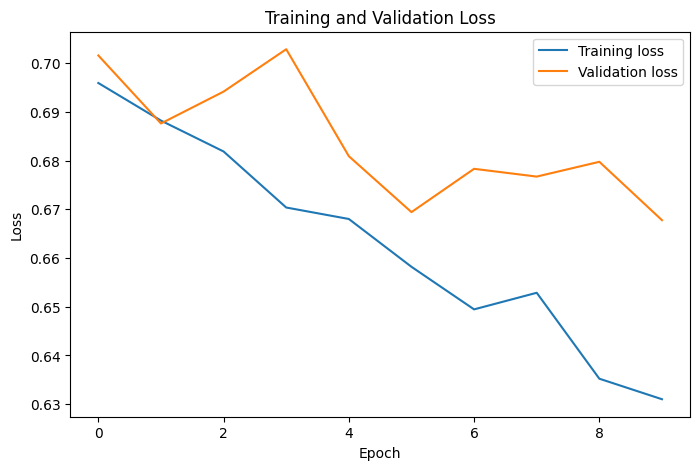

In [48]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training loss")
plt.plot(validation_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [49]:
# Prediction function
def predict(data_loader):
    classifier.eval()

    probabilities = []
    true_labels = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)

            logits = classifier(features)
            batch_probabilities = torch.sigmoid(logits).cpu().numpy()

            probabilities.extend(batch_probabilities.flatten())
            true_labels.extend(labels.numpy().flatten())

    predicted_labels = [
        1 if probability >= 0.5 else 0
        for probability in probabilities
    ]

    return np.array(true_labels), np.array(predicted_labels), np.array(probabilities)

In [50]:
# Tune threshold on validation set to maximize F1-score.
validation_true_labels, _, validation_probabilities = predict(validation_loader)

# Try several thresholds between 0.30 and 0.80.
thresholds = np.arange(0.30, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    threshold_predictions = [
        1 if probability >= threshold else 0
        for probability in validation_probabilities
    ]

    threshold_precision = precision_score(
        validation_true_labels,
        threshold_predictions,
        zero_division=0
    )

    threshold_recall = recall_score(
        validation_true_labels,
        threshold_predictions,
        zero_division=0
    )

    threshold_f1 = f1_score(
        validation_true_labels,
        threshold_predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": threshold_precision,
        "recall": threshold_recall,
        "f1": threshold_f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold = threshold_results_df.sort_values(
    "f1",
    ascending=False
).iloc[0]["threshold"]

print(threshold_results_df)
print("Best threshold:", best_threshold)

    threshold  precision    recall        f1
0        0.30   0.491150  0.948718  0.647230
1        0.35   0.474178  0.863248  0.612121
2        0.40   0.485149  0.837607  0.614420
3        0.45   0.500000  0.803419  0.616393
4        0.50   0.506024  0.717949  0.593640
5        0.55   0.572581  0.606838  0.589212
6        0.60   0.658824  0.478632  0.554455
7        0.65   0.848485  0.239316  0.373333
8        0.70   1.000000  0.025641  0.050000
9        0.75   0.000000  0.000000  0.000000
10       0.80   0.000000  0.000000  0.000000
Best threshold: 0.3


In [51]:
# Evaluate test set using the validation-tuned threshold.
true_labels, _, probabilities = predict(test_loader)

predicted_labels = [
    1 if probability >= best_threshold else 0
    for probability in probabilities
]

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, zero_division=0)
recall = recall_score(true_labels, predicted_labels, zero_division=0)
f1 = f1_score(true_labels, predicted_labels, zero_division=0)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

print("Best threshold:", best_threshold)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("\nConfusion matrix:")
print(conf_matrix)

Best threshold: 0.3
Accuracy: 0.536
Precision: 0.5299539170506913
Recall: 0.8914728682170543
F1-score: 0.6647398843930635

Confusion matrix:
[[ 19 102]
 [ 14 115]]


In [52]:
# Load challenge dataset.
# challenge_path is configured in the first cell.
challenge_df = pd.read_json(challenge_path, lines=True)

print("Challenge samples:", len(challenge_df))
challenge_df.head()

Challenge samples: 1000


,vul_id,func
0,29479,private static native void nativeSetApkAssets(...
1,12129,@Override\n public byte readByte() throws J...
2,23206,"@GetMapping(""/logout"")\n public String logo..."
3,33195,@Override\n\tprotected void onStart() {\n\t\ts...
4,17577,"public static boolean zipAll(File rootFile, Fi..."


In [53]:
# create challenge embeddings
X_challenge = create_embeddings(
    challenge_df["func"].tolist(),
    max_length=128
)

challenge_loader = DataLoader(
    TensorDataset(
        X_challenge,
        torch.zeros(len(X_challenge), 1)
    ),
    batch_size=32,
    shuffle=False
)

Embedding batch 1/63
Embedding batch 10/63
Embedding batch 20/63
Embedding batch 30/63
Embedding batch 40/63
Embedding batch 50/63
Embedding batch 60/63
Embedding batch 63/63


In [55]:
# Predict challenge labels using the validation-tuned threshold.
classifier.eval()

challenge_probabilities = []

with torch.no_grad():
    for features, _ in challenge_loader:
        features = features.to(device)

        logits = classifier(features)
        probabilities = torch.sigmoid(logits).cpu().numpy()

        challenge_probabilities.extend(probabilities.flatten())

challenge_predictions = [
    1 if probability >= best_threshold else 0
    for probability in challenge_probabilities
]

In [ ]:
# Save the best-upload submission.
# Best results were obtained using the improved MLP and a threshold of 0.40.
final_threshold = 0.40

challenge_predictions = [
    1 if probability >= final_threshold else 0
    for probability in challenge_probabilities
]

submission_df = pd.DataFrame({
    "vul_id": challenge_df["vul_id"],
    "is_vul": challenge_predictions
})

# submission_path is configured in the first cell.
submission_df.to_csv(submission_path, index=False)

print("Final threshold:", final_threshold)
print("Saved submission to:", submission_path)
print(submission_df["is_vul"].value_counts())
submission_df.head()


Saved submission to: /content/drive/MyDrive/CDS_Part3/part3_challenge_predictions_3.csv
is_vul
1    826
0    174
Name: count, dtype: int64


,vul_id,is_vul
0,29479,1
1,12129,1
2,23206,1
3,33195,0
4,17577,1
